<a href="https://colab.research.google.com/github/Khuc-Ngoc-Nam/Training-AIO-/blob/main/Module%201/Human_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Bước 1**: Tải source code của YOLO trên github
**1.** Truy cập trang [here](https://github.com/ultralytics/ultralytics)

**2.** Tại trang GitHub của YOLOv8, chọn mục `Code` (có màu nền xanh lá
như ảnh dưới) và chọn nút copy đường dẫn như ảnh minh họa dưới đây:
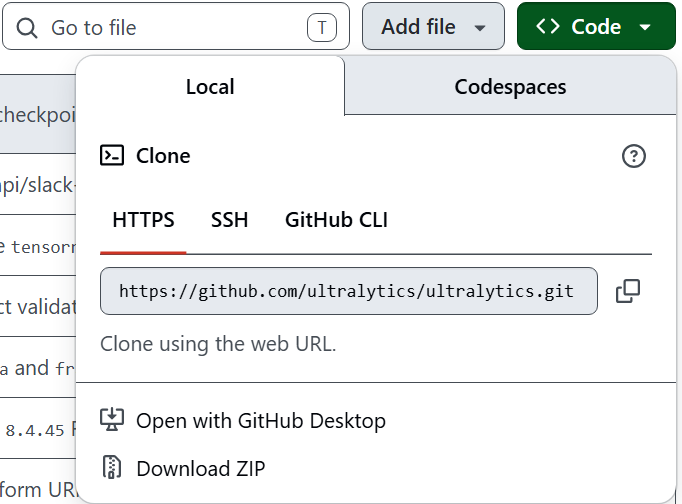

**3:** Quay lại Google Colab, các bạn khởi tạo một code cell sử dụng lệnh: !git clone `<link>`
(trong đó `<link>` là đường dẫn GitHub đã copy ở `2`).


In [ ]:
!git clone https://github.com/ultralytics/ultralytics.git

Cloning into 'ultralytics'...
remote: Enumerating objects: 99761, done.
remote: Counting objects: 100% (474/474), done.
remote: Compressing objects: 100% (217/217), done.
remote: Total 99761 (delta 390), reused 266 (delta 257), pack-reused 99287 (from 4)
Receiving objects: 100% (99761/99761), 53.55 MiB | 16.75 MiB/s, done.
Resolving deltas: 100% (74832/74832), done.


# **Bước 2:** Cài các gói thư viện Python cần thiết theo yêu cầu của YOLOv8
Mã nguồn
YOLOv8 được xây dựng bằng rất nhiều các thư viện Python khác nhau. Vì vậy, để có thể chạy
được YOLOv8 ta cần tải các gói thư viện cần thiết mà YOLOv8 yêu cầu. YOLOv8 có hỗ trợ sẵn
thư viện tên ultralytics, chúng ta có thể tải thư viện này thông qua lệnh pip như sau:

In [ ]:
%cd ultralytics
!pip install ultralytics
import ultralytics

ultralytics.checks()

WARNING ⚠️ Multiple Ultralytics installations detected. The `yolo` command uses: /usr/local/lib/python3.12/dist-packages/ultralytics, but current session imports from: /content/ultralytics/ultralytics. This may cause version conflicts. Install your local copy in editable mode with 'pip install -e /content/ultralytics' to avoid issues. See https://docs.ultralytics.com/quickstart/
Ultralytics 8.4.46 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 43.2/112.6 GB disk)


# **Bước 3:** Tải pretrained-model
Tải file pretrained model tại [đây](https://github.com/ultralytics/assets/releases/download/v0.0.0/yolov8s.pt) và đặt file đã tải vào thư mục
`./ultralytics`. Trên Google Colab, việc này có thể được thực hiện thông qua lệnh `wget`.

In [ ]:
!wget https://github.com/ultralytics/assets/releases/download/v0.0.0/yolov8s.pt

--2026-05-05 11:27:24--  https://github.com/ultralytics/assets/releases/download/v0.0.0/yolov8s.pt
Resolving github.com (github.com)... 140.82.113.4
Connecting to github.com (github.com)|140.82.113.4|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://release-assets.githubusercontent.com/github-production-release-asset/521807533/e329fea7-51a3-4380-b8ab-3d9b4efc69e5?sp=r&sv=2018-11-09&sr=b&spr=https&se=2026-05-05T12%3A18%3A04Z&rscd=attachment%3B+filename%3Dyolov8s.pt&rsct=application%2Foctet-stream&skoid=96c2d410-5711-43a1-aedd-ab1947aa7ab0&sktid=398a6654-997b-47e9-b12b-9515b896b4de&skt=2026-05-05T11%3A17%3A59Z&ske=2026-05-05T12%3A18%3A04Z&sks=b&skv=2018-11-09&sig=FRduh9SAoWQ0TRGFPJkymdDZUd9Dc9Txg8%2FPC7zeq9A%3D&jwt=eyJ0eXAiOiJKV1QiLCJhbGciOiJIUzI1NiJ9.eyJpc3MiOiJnaXRodWIuY29tIiwiYXVkIjoicmVsZWFzZS1hc3NldHMuZ2l0aHVidXNlcmNvbnRlbnQuY29tIiwia2V5Ijoia2V5MSIsImV4cCI6MTc3Nzk4MjI0NCwibmJmIjoxNzc3OTgwNDQ0LCJwYXRoIjoicmVsZWFzZWFzc2V0cHJvZHVjdGlvbi5ibG9iLmNvcmU

Trong `ultralytics\ultralytics` đã có file `yolov8s.pt`. => Đã tải thành công Pretrained model

# **Bước 4:** Chuẩn bị dữ liệu
$$\text{Để huấn luyện YOLOv8 trên một bộ dữ liệu bất kì, ta cần 2 thành phần chính:}$$


## I. Thư mục chứa dữ liệu:
Cần chuẩn bị một thư mục chứa bộ dữ liệu, cấu trúc cây thư mục như sau:
```
human_detection_dataset
├── train
│   ├── images    # Chứa các file ảnh (.jpg, .png)
│   ├── labels    # Chứa các file .txt tương ứng với từng ảnh (có cùng tên file trong folder images)
├── val
│   ├── images
│   ├── labels
├── data.yaml     # file config ở phần II. File.yaml

```

In [ ]:
%cd /content

/content


In [ ]:
!gdown https://drive.google.com/u/0/uc?id=1--0QuKMwj31K-CSvD8oq5fceFweiFPuN&export=download
!unzip /content/human_detection_dataset.zip

Kết quả truyền trực tuyến bị cắt bớt đến 5000 dòng cuối.
  inflating: human_detection_dataset/train/labels/frame204006.30.00-06.35.00.txt  
  inflating: human_detection_dataset/train/labels/frame402008.05.00-08.10.00.txt  
  inflating: human_detection_dataset/train/labels/frame24006.55.00-07.00.00.txt  
  inflating: human_detection_dataset/train/labels/frame156008.00.00-08.05.00.txt  
  inflating: human_detection_dataset/train/labels/frame552007.55.00-08.00.00.txt  
  inflating: human_detection_dataset/train/labels/frame90006.35.00-06.40.00.txt  
  inflating: human_detection_dataset/train/labels/frame126006.30.00-06.35.00.txt  
  inflating: human_detection_dataset/train/labels/frame582006.20.00-06.25.00.txt  
  inflating: human_detection_dataset/train/labels/frame582008.00.00-08.05.00.txt  
  inflating: human_detection_dataset/train/labels/frame342007.10.00-07.15.00.txt  
  inflating: human_detection_dataset/train/labels/frame150006.45.00-06.50.00.txt  
  inflating: human_detection_dat

## II. File `.yaml`:
- File chứa các thông tin về bộ dữ liệu được tải **phía trên**. Trong folder `human_detection_dataset`.

- Dưới đây là một số file `.yaml` được tác giả YOLOv8 cung cấp sẵn:

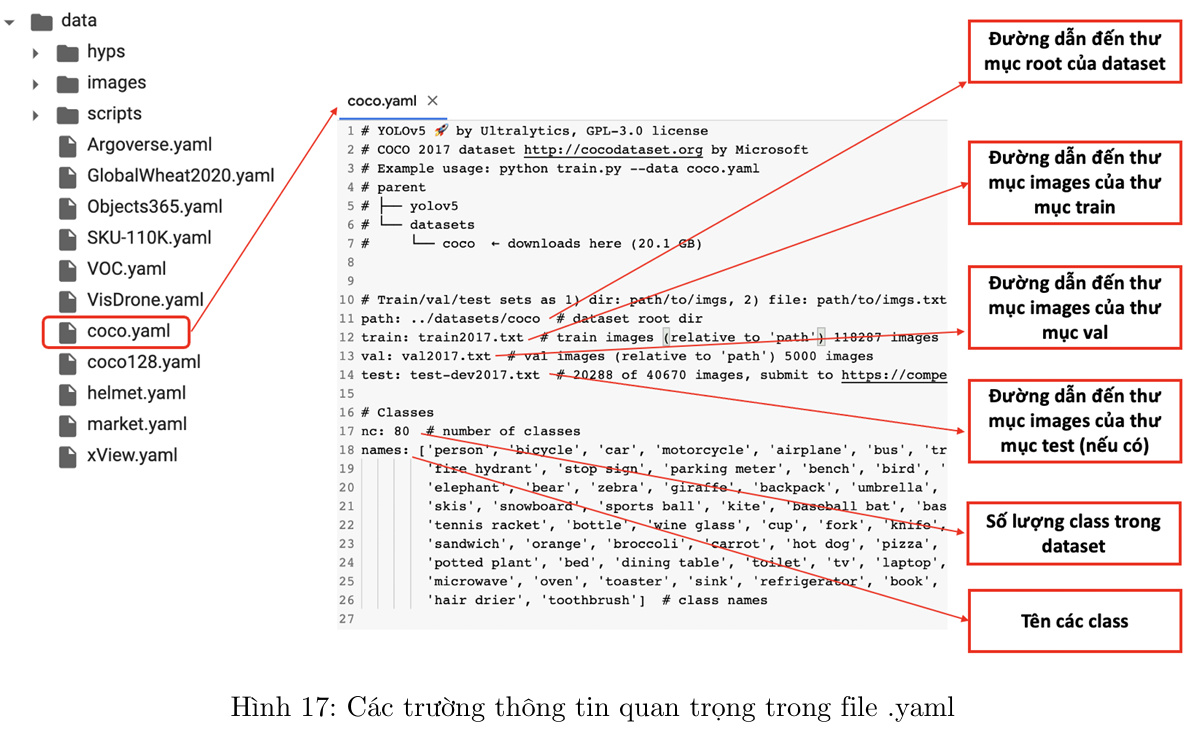

In [ ]:
import yaml

dataset_info = {
    'train': '/content/human_detection_dataset/train/images',
    'val': '/content/human_detection_dataset/val/images',  # <-- Thêm /images vào đây
    'nc': 1,
    'names': ['Human']
}

with open('./human_detection_dataset/data.yaml', 'w+') as f:
    doc = yaml.dump(dataset_info, f, default_flow_style=None, sort_keys=False)

# **Bước 5:** Thực hiện huấn luyện

In [ ]:
!yolo train model=yolov8s.pt data=./human_detection_dataset/data.yaml epochs=20 imgsz=640

Ultralytics 8.4.46 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=./human_detection_dataset/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=20, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train-2, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patie

# **Bước 6:** Detection
Để sử dụng mô hình đã huấn luyện lên một tấm ảnh bất kì, ta dùng câu lệnh:

```
# With uploaded image
!yolo predict model = <weight_path> source=<image_path>
```

**Trong đó:**
- `<weight_path>`: Đường dẫn đến file weight của mô hình sau khi kết thúc quá trình huấn luyện.

```
      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      20/20      3.89G     0.7423       0.49     0.9237         95        640: 100% ━━━━━━━━━━━━ 139/139 2.5it/s 56.2s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 52/52 2.0it/s 25.9s
                   all       1642      13171      0.826      0.691      0.795      0.529

20 epochs completed in 0.497 hours.
Optimizer stripped from /content/ultralytics/runs/detect/train-2/weights/last.pt, 22.5MB
Optimizer stripped from /content/ultralytics/runs/detect/train-2/weights/best.pt, 22.5MB
```

**Cell output** Đường dẫn đến file weight của mô hình đã huấn luyện. **Lưu ý** chọn file `best.pt`

*Bên cạnh source về cảnh, có thể input source với các tham số khác nhau, đại diện cho các dữ liệu đầu vào khác nhau.*

$\text{Dưới đây là các kiểu dữ liệu đầu vào YOLOv8 hỗ trợ trong việc thực hiện predict}$:

| source | model(arg) | type | notes |
| :--- | :--- | :--- | :--- |
| image | `'im.jpg'` | `str`, `Path` | |
| URL | `'https://ultralytics.com/images/bus.jpg'` | `str` | |
| screenshot | `'screen'` | `str` | |
| PIL | `Image.open('im.jpg')` | `PIL.Image` | HWC, RGB |
| OpenCV | `cv2.imread('im.jpg')` | `np.ndarray` | HWC, BGR |
| numpy | `np.zeros((640,1280,3))` | `np.ndarray` | HWC |
| torch | `torch.zeros(16,3,320,640)` | `torch.Tensor` | BCHW, RGB |
| CSV | `'sources.csv'` | `str`, `Path` | RTSP, RTMP, HTTP |
| video ✅ | `'vid.mp4'` | `str`, `Path` | |
| directory ✅ | `'path/'` | `str`, `Path` | |
| glob ✅ | `'path/*.jpg'` | `str` | Use `*` operator |
| YouTube ✅ | `'https://youtu.be/Zgi9g1ksQHc'` | `str` | |
| stream ✅ | `'rtsp://example.com/media.mp4'` | `str` | RTSP, RTMP, HTTP |

In [ ]:
!yolo predict model = /content/ultralytics/runs/detect/train-2/weights/best.pt source = 'https://danviet.ex-cdn.com/files/f1/296231569849192448/2022/12/10/dd8gqutgronaldo-wc-afp625x30010december22-16706942213551984075591.jpeg'

Ultralytics 8.4.46 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 11,125,971 parameters, 0 gradients, 28.4 GFLOPs

image 1/1 /content/dd8gqutgronaldo-wc-afp625x30010december22-16706942213551984075591.jpeg: 480x640 1 Human, 44.5ms
Speed: 2.9ms preprocess, 44.5ms inference, 16.6ms postprocess per image at shape (1, 3, 480, 640)
Results saved to /content/ultralytics/runs/detect/predict-2
💡 Learn more at https://docs.ultralytics.com/modes/predict


Tìm thấy 1 ảnh kết quả:
Hiển thị: /content/ultralytics/runs/detect/predict-2/dd8gqutgronaldo-wc-afp625x30010december22-16706942213551984075591.jpg


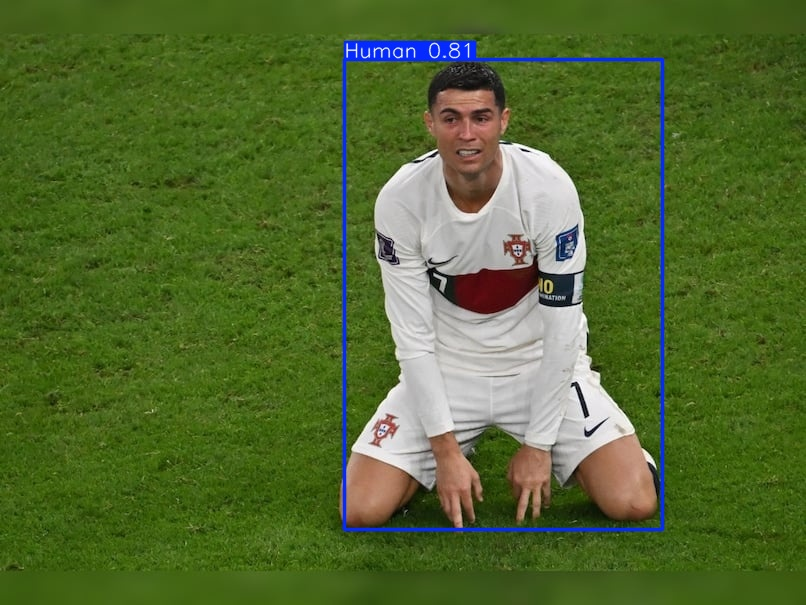

In [ ]:
import glob
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from IPython.display import display, Image

predict_path = '/content/ultralytics/runs/detect/predict-2'

# Lấy danh sách tất cả các file ảnh (.jpg hoặc .png) trong thư mục
images = glob.glob(f'{predict_path}/*.jpg') + glob.glob(f'{predict_path}/*.png')

if not images:
    print(f"Không tìm thấy ảnh nào trong thư mục: {predict_path}")
else:
    print(f"Tìm thấy {len(images)} ảnh kết quả:")
    for img_path in images:
        print(f"Hiển thị: {img_path}")
        display(Image(filename=img_path, width=600))

# Bàn luận thêm

- Các tham số trong lệnh training: Dòng lệnh training tại bước 6 có mặc định sẵn một vài tham số, các tham số này các bạn có thể tùy chỉnh theo ý muốn của mình, với một số tham số có giá trị khác nhau sẽ cho ra hiệu suất mô hình khác nhau. Sau đây là ý nghĩa cơ bản của một vài tham số trên:
  
  – `img`: Kích thước ảnh training, các ảnh train và test sẽ được resize lại về kích thước bạn gán, mặc định là 640. Các bạn hoàn toàn có thể thử nghiệm trên các kích thước ảnh khác nhau.
  
  – `batch`: Khi thực hiện tính toán trong quá trình training, các mô hình có thể đọc một lúc toàn bộ dữ liệu train hoặc chia ra đọc theo từng batch. Với mặc định là 64, bộ dữ liệu train sẽ được chia ra thành các batch có 64 mẫu dữ liệu. Các bạn có thể cài đặt các giá trị khác theo $2^n$(n ≥ 0).
  
  – `epochs`: Số lần lặp qua bộ dữ liệu trong quá trình huấn luyện.
  
  – `data`: Thông tin bộ dữ liệu (file .yaml) mà bạn mong muốn training.
  
  – `weights`: File pretrained model sử dụng. Các bạn có thể tải và sử dụng các file **pretrained model** khác nhau trong danh sách này.

- **Đánh giá mô hình:** Như đã nói ở phần trước, hiệu suất của mô hình có thể thay đổi với các giá trị tham số khác nhau. Để có tìm ra mô hình tốt nhất một cách định lượng, ta có thể thực hiện dòng lệnh sau:

```
!yolo val model=./run/detect/train2/weights/best.pt data=../human_detection_dataset/data.yaml
```

---
---
---
---
---

# **Skill bổ sung**: Gán nhãn dữ liệu `labelImg`
- Các mẫu dữ liệu cần có labels tương ứng với từng mẫu

=> Cần tạo bộ dữ liệu mới với class mới. => Phải thực hiện gán dữ liệu (thủ công).

**Bước 1:** Tải mã nguồn của `labelImg`
```
git clone https://github.com/heartexlabs/labelImg.git
```

**Bước 2:** Cài đặt Anaconda (nếu chưa cài đặt)

**Bước 3:** Khởi tạo môi trường Anaconda
```
conda create -n labelimg_env python=3.9 -y
```

**Bước 4:** Kích hoạt môi trường ảo đã tạo ở bước 3 sử dụng lệnh:
```
conda activate labeling_env
```

**Bước 5:** Di chuyển vào thư mục mã nguồn của labelImg sử dụng lệnh:
```
cd <path_to_labelImg_folder>
```

**Bước 6:** Thực hiện lần lượt các lệnh:
```
conda install pyqt=5
conda install -c anaconda lxml
pyrcc5 -o libs/resources.py resources.qrc
```

**Bước 7:** Khởi động giao diện của labelImg
```
python labelImg.py
```

*Về sau, mỗi lần cần sử dụng labelImg, ta chỉ cần kích hoạt môi trường đã tạo này và khởi
động labelImg (tức chỉ thực hiện `bước 4` và `bước 7`).*

## Các bước gán nhãn hình ảnh:
**Bước 1:**  Truy cập vào thư mục data trong mã nguồn labelImg, sửa lại nội dung file `predefined_classes.txt` bằng tên của các class trong bộ dữ liệu của bạn, mỗi tên class sẽ là một hàng trong file:

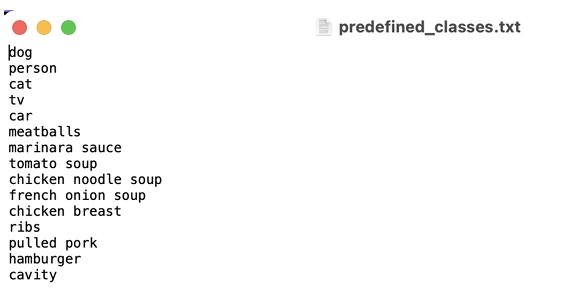

**Bước 2:** Truy cập vào giao diện `labelImg`, mở thư mục chứa ảnh cần gán nhãn và chuyển format nhãn thành `YOLO`

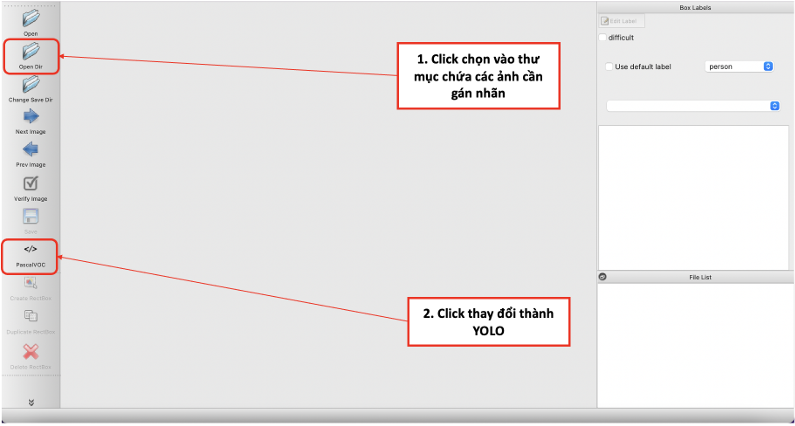

**Bước 3:** Nếu thành công thì giao diện như sau:

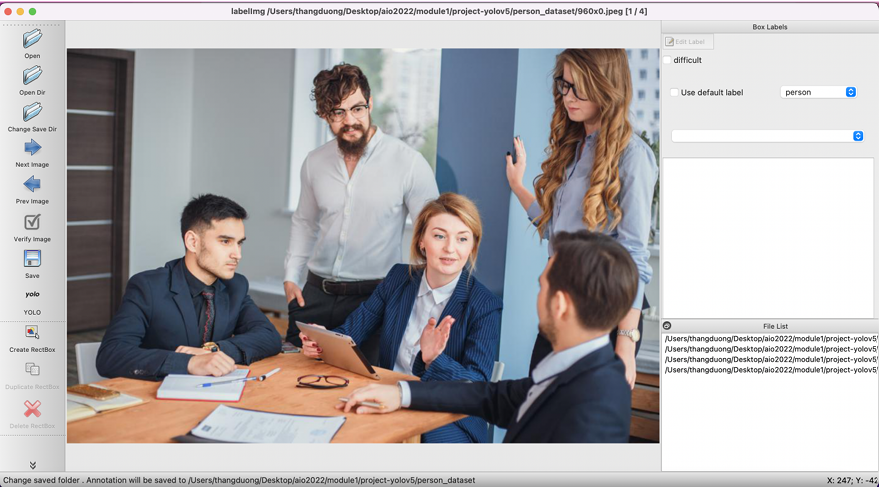

**Bước 4:** Thự hiện gán nhãn theo hình bên dưới:

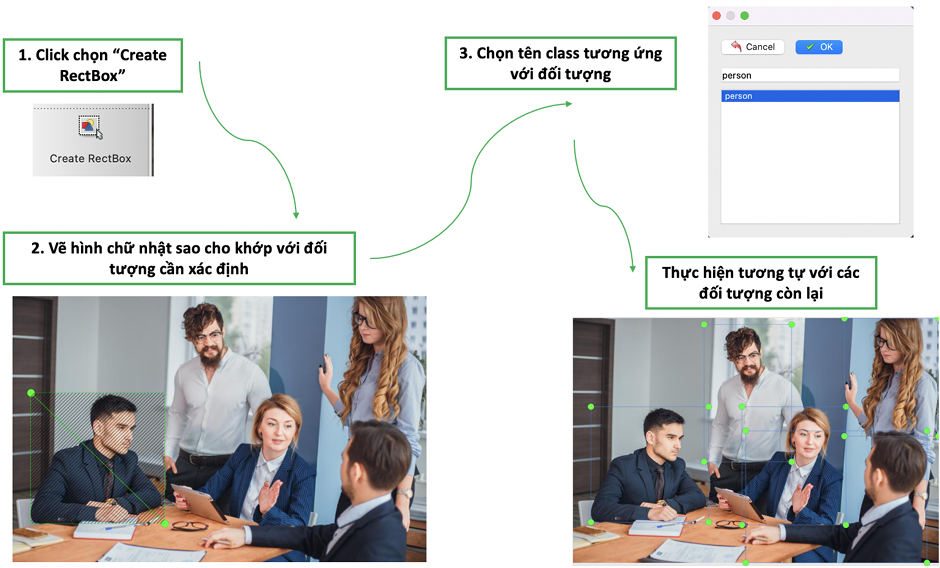

Sau khi kết thúc gán nhãn cho một ảnh, các bạn save lại **(CTRL + S)** và di chuyển đi
hình tiếp theo (phím **D (Next Image)** hoặc **phím A (Prev Image)**). Khi đã gán nhãn hết
tất cả các ảnh, các bạn có thể kiểm tra tại thư mục chứa ảnh của mình, nếu thấy các
**file .txt** cho từng ảnh bạn đã gán nhãn, bạn đã gán nhãn thành công:

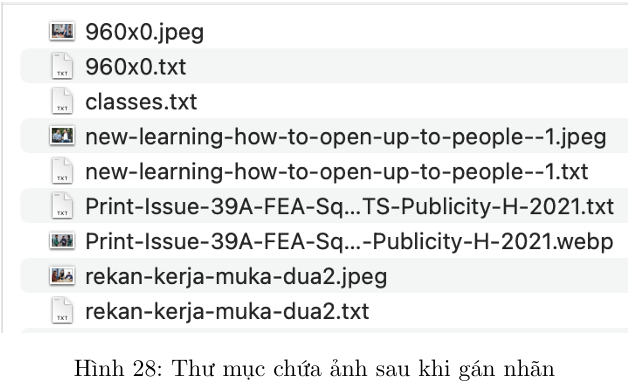

# QUIZ
```
1. c
2. a
3. d
4. c
5. b
6. d
7. a) Có vì .. là nhảy ra ngoài 1 cấp
8. Bên dưới
```

In [ ]:
!pip install yt-dlp

In [ ]:
!yolo predict model=/content/ultralytics/runs/detect/train-2/weights/best.pt \
      source='https://www.youtube.com/watch?v=MsXdUtlDVhk' \
      save=True